# The Music Map: Music Recommendation System

> Team: Strategic Chaos

In [1]:
import pandas as pd
import numpy as np

In [2]:
music_list= pd.read_csv("dataset/spotify_global_music_dataset.csv")
music_list.head()

,track_id,track_name,artist_name,collection_name,genre,content_rating,user_rating,track_price,collection_price,release_date,track_time_millis,country,currency,preview_url,artwork_url
0,6KwkVtXm8OUp2XffN5k7lY,No Other Name,Hillsong Worship,No Other Name,world-music,Clean,3.0,0.99,14.99,2023-05-10T00:00:00Z,440247,US,USD,https://p.scdn.co/mp3-preview/c0fb332cd79ab638...,https://i.scdn.co/image/ab67616d0000b273c0fb33...
1,2dp5I5MJ8bQQHDoFaNRFtX,Failed Organum,Internal Rot,Grieving Birth,grindcore,Clean,1.4,0.99,11.99,2014-08-13T00:00:00Z,93933,US,USD,https://p.scdn.co/mp3-preview/c2977f6a890e2ac5...,https://i.scdn.co/image/ab67616d0000b273c2977f...
2,5avw06usmFkFrPjX8NxC40,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,iranian,Clean,1.0,0.99,9.99,2022-06-16T00:00:00Z,213578,US,USD,https://p.scdn.co/mp3-preview/59987b268b85d1a1...,https://i.scdn.co/image/ab67616d0000b27359987b...
3,75hT0hvlESnDJstem0JgyR,Merry Christmas,Bryan Adams,All I Want For Christmas Is You,rock,Clean,1.0,0.99,9.99,2015-05-12T00:00:00Z,151387,US,USD,https://p.scdn.co/mp3-preview/c67bea4b3464628b...,https://i.scdn.co/image/ab67616d0000b273c67bea...
4,4bY2oZGA5Br3pTE1Jd1IfY,æã®å¤§ãã,Nogizaka46,ãã¬ãã¿ TypeD,j-idol,Clean,3.3,1.29,14.99,2019-07-10T00:00:00Z,236293,US,USD,https://p.scdn.co/mp3-preview/d4cdd835ec630a33...,https://i.scdn.co/image/ab67616d0000b273d4cdd8...


### Preprocessing

> 

In [3]:
# to get the count of every genre present  //-> not part of preprocessing
music_list['genre'].value_counts()

genre
grindcore      122
alt-rock       112
dubstep        110
industrial     110
blues          109
              ... 
alternative     77
death-metal     76
trance          76
sad             75
turkish         74
Name: count, Length: 114, dtype: int64

In [4]:
# Replacing the dataset with features important for our model.

music_list= music_list[["track_id","track_name","artist_name","collection_name","genre","release_date"]]
music_list

,track_id,track_name,artist_name,collection_name,genre,release_date
0,6KwkVtXm8OUp2XffN5k7lY,No Other Name,Hillsong Worship,No Other Name,world-music,2023-05-10T00:00:00Z
1,2dp5I5MJ8bQQHDoFaNRFtX,Failed Organum,Internal Rot,Grieving Birth,grindcore,2014-08-13T00:00:00Z
2,5avw06usmFkFrPjX8NxC40,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,iranian,2022-06-16T00:00:00Z
3,75hT0hvlESnDJstem0JgyR,Merry Christmas,Bryan Adams,All I Want For Christmas Is You,rock,2015-05-12T00:00:00Z
4,4bY2oZGA5Br3pTE1Jd1IfY,æã®å¤§ãã,Nogizaka46,ãã¬ãã¿ TypeD,j-idol,2019-07-10T00:00:00Z
...,...,...,...,...,...,...
10509,6t7BIMqtZzTNJbgjIBayS8,å¬ã®ããæ¥ã®å,GReeeeN,å¡©ãã³ã·ã§ã¦,j-rock,2017-09-20T00:00:00Z
10510,68gi1yEZqkzKJPiUeZe8bI,OÃ­r Tu Voz,Los Estramboticos,LÃ¡grimas y Risas,alt-rock,2017-04-19T00:00:00Z
10511,3qgtGhoCutbBX73cd6ArCW,SouthSide (feat. Eptic),DJ Snake;Eptic,Carte Blanche,electronic,2023-11-14T00:00:00Z
10512,3aLFCYGyw3BBySQ8GEZsuY,Time Warp,Cooltime Kids,Halloween Music for Kids,kids,2022-03-13T00:00:00Z


In [5]:
# count the number of null entries in our dataset

music_list.isnull().sum()

track_id           0
track_name         1
artist_name        1
collection_name    1
genre              0
release_date       0
dtype: int64

In [6]:
# dropping the rows containing null enries

music_list= music_list.dropna()

In [7]:
music_list.shape

(10513, 6)

In [8]:
# music_list.columns
music_list.head()

,track_id,track_name,artist_name,collection_name,genre,release_date
0,6KwkVtXm8OUp2XffN5k7lY,No Other Name,Hillsong Worship,No Other Name,world-music,2023-05-10T00:00:00Z
1,2dp5I5MJ8bQQHDoFaNRFtX,Failed Organum,Internal Rot,Grieving Birth,grindcore,2014-08-13T00:00:00Z
2,5avw06usmFkFrPjX8NxC40,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,iranian,2022-06-16T00:00:00Z
3,75hT0hvlESnDJstem0JgyR,Merry Christmas,Bryan Adams,All I Want For Christmas Is You,rock,2015-05-12T00:00:00Z
4,4bY2oZGA5Br3pTE1Jd1IfY,æã®å¤§ãã,Nogizaka46,ãã¬ãã¿ TypeD,j-idol,2019-07-10T00:00:00Z


In [9]:
# keeping only ASCII string in dataset

music_list= music_list[music_list['track_name'].apply(lambda x: x.isascii() if isinstance(x, str) else False)]
music_list= music_list[music_list['collection_name'].apply(lambda x: x.isascii() if isinstance(x, str) else False)]
music_list= music_list[music_list['artist_name'].apply(lambda x: x.isascii() if isinstance(x, str) else False)]
music_list.head()

,track_id,track_name,artist_name,collection_name,genre,release_date
0,6KwkVtXm8OUp2XffN5k7lY,No Other Name,Hillsong Worship,No Other Name,world-music,2023-05-10T00:00:00Z
1,2dp5I5MJ8bQQHDoFaNRFtX,Failed Organum,Internal Rot,Grieving Birth,grindcore,2014-08-13T00:00:00Z
2,5avw06usmFkFrPjX8NxC40,"Save the Trees, Pt. 1",Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,iranian,2022-06-16T00:00:00Z
3,75hT0hvlESnDJstem0JgyR,Merry Christmas,Bryan Adams,All I Want For Christmas Is You,rock,2015-05-12T00:00:00Z
5,2zQt5C0AIv27RhfJCRZdZ4,"Jah Jah Revolta, Pt. 2",BaianaSystem,Duas Cidades,samba,2015-04-18T00:00:00Z


In [10]:
music_list.shape

(8154, 6)

In [11]:
music_list['release_date'][0]

'2023-05-10T00:00:00Z'

In [12]:
# cleaning the release_date feature

def date(d):
    months= {
        "01":'jan',
        "02":'feb',
        "03":'mar',
        "04":'apr',
        "05":'may',
        "06":'june',
        "07":'july',
        "08":'aug',
        "09":'sept',
        "10":'oct',
        "11":'nov',
        "12":'dec'
    }

    return d[8:10]+months[d[5:7]]+d[2:4]

music_list['release_date']= music_list['release_date'].apply(date)

In [13]:
# replacing the ' ' (space between word) to '' (no space between words)

music_list['artist_name']    = music_list['artist_name'].apply(lambda x: x.replace(' ', ''))
music_list['collection_name']= music_list['collection_name'].apply(lambda x: x.replace(' ', ''))
music_list['genre']          = music_list['genre'].apply(lambda x: x.replace(' ', ''))

In [14]:
# Creating a 'Tag' feature

music_list['tag']= music_list['artist_name']+' '+music_list['collection_name']+' '+music_list['genre']+' '+music_list['release_date']
music_list.head()

,track_id,track_name,artist_name,collection_name,genre,release_date,tag
0,6KwkVtXm8OUp2XffN5k7lY,No Other Name,HillsongWorship,NoOtherName,world-music,10may23,HillsongWorship NoOtherName world-music 10may23
1,2dp5I5MJ8bQQHDoFaNRFtX,Failed Organum,InternalRot,GrievingBirth,grindcore,13aug14,InternalRot GrievingBirth grindcore 13aug14
2,5avw06usmFkFrPjX8NxC40,"Save the Trees, Pt. 1",ZhoobinAskarieh;AliSasha,NoiseANoise20.4-1,iranian,16june22,ZhoobinAskarieh;AliSasha NoiseANoise20.4-1 ira...
3,75hT0hvlESnDJstem0JgyR,Merry Christmas,BryanAdams,AllIWantForChristmasIsYou,rock,12may15,BryanAdams AllIWantForChristmasIsYou rock 12may15
5,2zQt5C0AIv27RhfJCRZdZ4,"Jah Jah Revolta, Pt. 2",BaianaSystem,DuasCidades,samba,18apr15,BaianaSystem DuasCidades samba 18apr15


In [15]:
import re
music_list['tag'] = music_list['tag'].apply(lambda x: re.sub(r'[;,\|/]', '', x))

In [16]:
# Converting each alphabet in the dataset to lowercase

music_list['tag']= music_list['tag'].apply(lambda x: x.lower())

In [17]:
music_list['tag'][0]

'hillsongworship noothername world-music 10may23'

In [18]:
#!pip install nltk

In [19]:
# Stemming the tags (i.e. replacing words to their root form)

from nltk.stem import PorterStemmer

ps= PorterStemmer()
def stem(text):
    y= []

    for i in text.split():
        y.append(ps.stem(i))

    return " ".join(y)

music_list['tag']= music_list['tag'].apply(stem)

In [20]:
for i in music_list['tag']:
    print(i)

hillsongworship noothernam world-mus 10may23
internalrot grievingbirth grindcor 13aug14
zhoobinaskariehalisasha noiseanoise20.4-1 iranian 16june22
bryanadam alliwantforchristmasisy rock 12may15
baianasystem duascidad samba 18apr15
joederosa youletmedown comedi 04mar19
canehil aformofprotest metalcor 06apr23
kano i'mready(discomix-original12inchversion) disco 06mar17
kaceymusgraveslanadelrey jinglebellrock2022 countri 05aug14
jebroerpaulelstakthebeatkrush megabber(djpaulelstak&thebeatkrusherremix) hardstyl 29mar18
wittlowryavamax intoyourarms(feat.avamax) pop 22mar21
laloebratttrap frescurayperreo regga 02aug14
linkinpark onemorelight metal 16july20
billieeilish halloweenparty2022 electro 24apr23
zithmisanthropix machinespirit club 26mar22
christopherzondaflextyl mrchrishiphopdancemov kid 29apr14
chipe. hotterthanhous chicago-hous 29july23
tonymatterhorn jamaicanstyl j-danc 13sept18
apacheindian timeforchang dancehal 21apr16
annaleighashford sundayintheparkwithgeorge(2017broadwaycastrec

### Vectorization

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

In [22]:
vect= CountVectorizer(max_features= 1000)


vector= vect.fit_transform(music_list['tag']).toarray()
vector

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(8154, 1000))

In [23]:
vect.get_feature_names_out()

array(['01apr22', '01aug21', '01dec16', '01feb21', '01jan23', '01june15',
       '01june19', '01may18', '01nov17', '01nov22', '01sept14', '02apr22',
       '02dec15', '02dec16', '02jan22', '02mar21', '02may20', '02nov23',
       '02sept20', '03apr16', '03aug16', '03aug19', '03aug21', '03feb17',
       '03jan15', '03jan18', '03nov16', '03nov18', '03nov20', '03nov22',
       '03oct22', '03sept14', '03sept19', '03sept20', '03sept21',
       '04apr14', '04apr21', '04feb16', '04feb23', '04july20', '04mar16',
       '04may21', '04sept16', '05apr15', '05apr18', '05aug16', '05aug22',
       '05jan17', '05mar19', '05mar22', '05nov19', '05oct20', '06aug18',
       '06aug22', '06dec18', '06dec19', '06jan18', '06june18', '06june22',
       '06mar18', '06mar19', '06may22', '06sept14', '07dec17', '07jan14',
       '07july23', '07june21', '07june22', '07mar23', '07nov22',
       '07oct17', '08apr21', '08dec15', '08feb22', '08july23', '08mar22',
       '08nov18', '09aug17', '09aug23', '09dec19', '09de

### Visualization

C:\Users\thena\AppData\Local\Temp\ipykernel_13112\1248277005.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako')


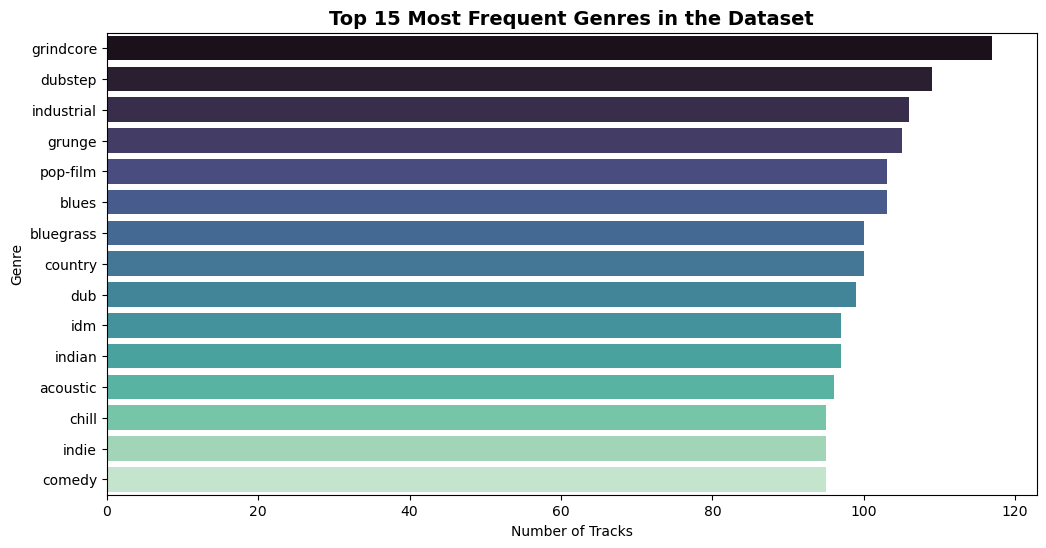

In [24]:
# --- EDA: Exploring the Data ---
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the top 15 genres
plt.figure(figsize=(12, 6))
top_genres = music_list['genre'].value_counts().head(15)

# Bar chart
sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako')
plt.title('Top 15 Most Frequent Genres in the Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tracks')
plt.ylabel('Genre')
plt.show()

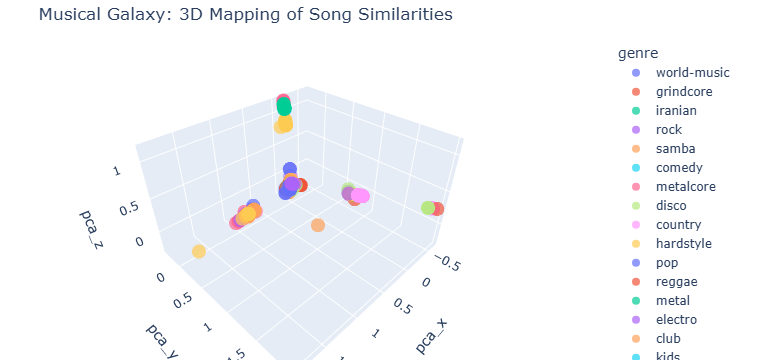

In [25]:
# --- 3D Dimensionality Reduction & Visualization ---
from sklearn.decomposition import PCA
import plotly.express as px

# 1. Converting 1000 dimensions into 3
pca = PCA(n_components=3)
vector_3d = pca.fit_transform(vector)

# 2. Adding new 3D coordinates back into the dataframe
music_list['pca_x'] = vector_3d[:, 0]
music_list['pca_y'] = vector_3d[:, 1]
music_list['pca_z'] = vector_3d[:, 2]

# 3. Creating an interactive 3D scatter plot!
# Coloring the points by genre.
fig = px.scatter_3d(
    music_list, 
    x='pca_x', 
    y='pca_y', 
    z='pca_z',
    color='genre',           # Color-coded by genre
    hover_name='track_name', # Shows track name when you hover
    hover_data=['artist_name'],
    title="Musical Galaxy: 3D Mapping of Song Similarities",
    opacity=0.7
)

# Render the interactive graph! (You can click and drag to rotate it)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

### Similarity prediction

In [26]:
# using cosine similarity for finding the similarities between the musics.
from sklearn.metrics.pairwise import cosine_similarity
# since disance is inverse to similarity, we can also use cosine_distances

In [27]:
# Calculating cosine similarity between vectors

vect_similarity= cosine_similarity(vector)

In [28]:
vect_similarity.shape

(8154, 8154)

In [29]:
for i in vect_similarity[0]:
    print(i)

1.0000000000000002
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.5773502691896258
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.5163977794943223
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.6666666666666669
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


### Recommendation engine(function)

In [30]:
def recommendation_engine(song):
    
    indexing= music_list[music_list['track_name'] == song].index[0]
    distances= vect_similarity[indexing]
    song_list= sorted(list(enumerate(distances)), reverse= True, key= lambda x:x[1])[1:6]

    for i in song_list:
        print(music_list.iloc[i[0]].track_name)
        # print(i)

In [31]:
recommendation_engine("Dil Dhadakne Do")

Leech
Chainsaw Gutsfuck
Let There Be Sodomy
In Shrouds Decayed
Failures Burden


### Code for webpage stuff

In [32]:
# import pickle

In [33]:
# pickle.dump(music_list.to_dict(), open("musics.pkl", "wb"))

In [34]:
# pickle.dump(vect_similarity, open("similarities.pkl", "wb"))